# 01 — Rate decomposition: Kitagawa, Das Gupta, and replacement

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Derive the two-factor rate decomposition.
- Recognize path dependence with three or more factors.
- Implement symmetric and stepwise allocations.

## Roadmap and notation

### Guiding question

When an aggregate conversion rate changes, how much is associated with a different mix of users and how much with different conversion rates inside the same segments?

### Prerequisites

Weighted averages and percentage-point changes. Notebook 00's distinction between contribution and causation is assumed.

### Symbols

| Symbol | Meaning |
|---|---|
| $g$ | segment, such as channel or customer type |
| $t\in\{0,1\}$ | baseline and comparison periods |
| $w_{gt}$ | share of observations in segment $g$; $\sum_gw_{gt}=1$ |
| $r_{gt}$ | rate inside segment $g$ |
| $R_t$ | aggregate rate $\sum_gw_{gt}r_{gt}$ |
| $C_w,C_r$ | mix and within-segment-rate contributions |

We first establish the identity, then calculate it, interpret the output, and finally test whether the answer changes when segments are aggregated.

## Kitagawa identity: intuition

For group $g$, the aggregate rate is $R_t=\sum_g w_{gt}r_{gt}$. Kitagawa's symmetric allocation is
$$C_w=\sum_g(w_{g1}-w_{g0})(r_{g1}+r_{g0})/2,$$
$$C_r=\sum_g(r_{g1}-r_{g0})(w_{g1}+w_{g0})/2.$$
Then $C_w+C_r=R_1-R_0$ exactly. These are composition and within-group-rate components—not causal effects. Das Gupta generalized standardization to several factors. Stepwise replacement is exact but generally order-dependent; averaging all orders produces a Shapley-style symmetric allocation.

## Kitagawa: derivation and proof of exactness

We want to decompose the change in the aggregate rate

$$R_t=\sum_{g=1}^{G}w_{gt}r_{gt},\qquad \sum_{g=1}^{G}w_{gt}=1.$$

Define $\Delta w_g=w_{g1}-w_{g0}$ and $\Delta r_g=r_{g1}-r_{g0}$. For one segment,

$$w_{g1}r_{g1}-w_{g0}r_{g0}
=(w_{g0}+\Delta w_g)(r_{g0}+\Delta r_g)-w_{g0}r_{g0}.$$

Expanding the product gives

$$w_{g1}r_{g1}-w_{g0}r_{g0}
=r_{g0}\Delta w_g+w_{g0}\Delta r_g+\Delta w_g\Delta r_g.$$

The first term is a pure mix change evaluated at the baseline rate; the second is a pure rate change evaluated at the baseline share; the third is an interaction because both quantities changed. Kitagawa allocates half of that interaction to each component:

$$C_{w,g}=r_{g0}\Delta w_g+\frac12\Delta w_g\Delta r_g
=\Delta w_g\frac{r_{g0}+r_{g1}}{2},$$

$$C_{r,g}=w_{g0}\Delta r_g+\frac12\Delta w_g\Delta r_g
=\Delta r_g\frac{w_{g0}+w_{g1}}{2}.$$

Adding the two components for one segment recovers its exact observed change:

$$C_{w,g}+C_{r,g}
=r_{g0}\Delta w_g+w_{g0}\Delta r_g+\Delta w_g\Delta r_g
=w_{g1}r_{g1}-w_{g0}r_{g0}.$$

Finally, summing over all segments proves the aggregate identity:

$$\boxed{R_1-R_0=\sum_g C_{w,g}+\sum_g C_{r,g}}.$$

The 50/50 interaction split makes the decomposition symmetric under reversal of periods. It is a defensible convention, not a uniquely identified scientific effect.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

In [2]:
# One row per stable customer segment; shares sum to one in each period.
d = pd.DataFrame({
    'segment': ['New', 'Returning', 'Enterprise'],
    'w0': [.50, .35, .15],
    'w1': [.42, .38, .20],
    'r0': [.08, .18, .31],
    'r1': [.10, .17, .34],
})

# Kitagawa's symmetric mix and rate contributions, calculated by segment.
d['mix'] = (d.w1 - d.w0) * (d.r1 + d.r0) / 2
d['rate'] = (d.r1 - d.r0) * (d.w1 + d.w0) / 2

R0 = (d.w0 * d.r0).sum()
R1 = (d.w1 * d.r1).sum()
summary = pd.Series({
    'R0': R0,
    'R1': R1,
    'change': R1 - R0,
    'mix': d['mix'].sum(),
    'rate': d['rate'].sum(),
    'error': (R1 - R0) - d[['mix', 'rate']].to_numpy().sum(),
})
d, summary

(      segment     w0     w1     r0     r1     mix    rate
 0         New 0.5000 0.4200 0.0800 0.1000 -0.0072  0.0092
 1   Returning 0.3500 0.3800 0.1800 0.1700  0.0053 -0.0036
 2  Enterprise 0.1500 0.2000 0.3100 0.3400  0.0163  0.0053,
 R0        0.1495
 R1        0.1746
 change    0.0251
 mix       0.0143
 rate      0.0108
 error    -0.0000
 dtype: float64)

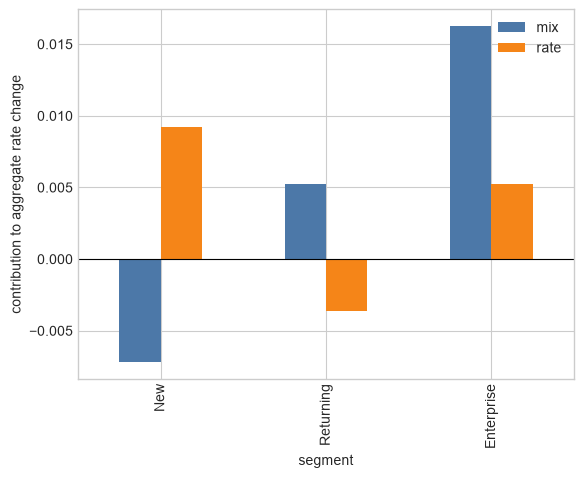

In [3]:
segment_contributions = d.set_index('segment')[['mix', 'rate']]
ax = segment_contributions.plot.bar(color=['#4C78A8', '#F58518'])
ax.axhline(0, color='black', linewidth=.8)
ax.set_ylabel('contribution to aggregate rate change')
plt.show()

## Reading the worked example

The aggregate rate rises from 0.1495 to 0.1746, a change of **0.0251**, or **2.51 percentage points**. The method allocates 1.43 pp to mix and 1.08 pp to within-segment rates. The near-zero `error` verifies the identity numerically.

At segment level, New users contribute negatively through mix because their traffic share falls, but positively through rate because their CVR improves. Enterprise contributes positively through both channels. Positive does not mean “good intervention”; it means positive contribution to the observed aggregate change under this rule.

## Growth-marketing case: conversion rate

Let $w_{gt}$ be the traffic share of channel $g$ and $r_{gt}$ its conversion rate. Then total CVR is $R_t=\sum_g w_{gt}r_{gt}$.

- **Mix contribution:** traffic moved toward channels with higher/lower CVR.
- **Rate contribution:** within-channel CVR changed.
- **Actionable diagnostic:** split further by device, geography, landing page, or cohort, but check sparse cells and post-treatment segmentation.

Example claim for the worked data: “Total CVR rose 2.51 pp; under the Kitagawa two-period rule, +1.43 pp is allocated to segment mix and +1.08 pp to within-segment rates.” This is precise and descriptive. “The new campaign caused +1.08 pp” is not supported without an experiment or credible quasi-experiment.

In [4]:
# Aggregation check: collapse Returning and Enterprise.
# The collapsed rate must be share-weighted separately in each period.
fine = d.copy()
collapsed = pd.DataFrame({
    'segment': ['New', 'Established'],
    'w0': [fine.loc[0, 'w0'], fine.loc[1:, 'w0'].sum()],
    'w1': [fine.loc[0, 'w1'], fine.loc[1:, 'w1'].sum()],
    'r0': [fine.loc[0, 'r0'],
           np.average(fine.loc[1:, 'r0'], weights=fine.loc[1:, 'w0'])],
    'r1': [fine.loc[0, 'r1'],
           np.average(fine.loc[1:, 'r1'], weights=fine.loc[1:, 'w1'])],
})
collapsed['mix'] = (collapsed.w1-collapsed.w0)*(collapsed.r1+collapsed.r0)/2
collapsed['rate'] = (collapsed.r1-collapsed.r0)*(collapsed.w1+collapsed.w0)/2

comparison = pd.DataFrame({
    'fine segmentation': [R0, R1, R1-R0, d['mix'].sum(), d['rate'].sum()],
    'collapsed segmentation': [
        (collapsed.w0*collapsed.r0).sum(),
        (collapsed.w1*collapsed.r1).sum(),
        (collapsed.w1*collapsed.r1).sum()-(collapsed.w0*collapsed.r0).sum(),
        collapsed['mix'].sum(),
        collapsed['rate'].sum(),
    ],
}, index=['R0','R1','total change','mix','rate'])
comparison

,fine segmentation,collapsed segmentation
R0,0.1495,0.1495
R1,0.1746,0.1746
total change,0.0251,0.0251
mix,0.0143,0.0107
rate,0.0108,0.0144


## Is the result consistent when segments are aggregated?

There are two different consistency questions.

### 1. Is the aggregate rate preserved? Yes—if aggregation is done correctly

For a block $H$ containing several fine segments, define

$$w_{Ht}=\sum_{g\in H}w_{gt},\qquad
r_{Ht}=\frac{\sum_{g\in H}w_{gt}r_{gt}}{w_{Ht}}.$$

Then $w_{Ht}r_{Ht}=\sum_{g\in H}w_{gt}r_{gt}$. Therefore $R_0$, $R_1$, and $R_1-R_0$ are exactly unchanged after collapsing segments. A simple unweighted average of rates would fail this property.

### 2. Are the mix and rate components preserved? Generally no

The fine decomposition evaluates every $\Delta w_g$ against its own average rate. The collapsed decomposition first creates a changing within-block weighted rate $r_{Ht}$ and then treats that block as one segment. Variation in shares **inside** $H$ is no longer visible as mix; part of it is absorbed into the block's rate component. Thus the total remains exact, while the labels `mix` and `rate` are reallocated.

This is not a coding inconsistency. It is a lack of **aggregation invariance**. The decomposition answers a question conditional on the chosen partition. Report the segmentation rule and repeat the analysis at substantively plausible levels.

## Stepwise Replacement: the bridge from Kitagawa to Das Gupta

Kitagawa has only two changing objects—shares and rates—and resolves their interaction by splitting it equally. When a function contains three or more changing factors, a simple alternative is to replace them **one at a time**.

Let

$$Y_t=F(x_{1t},x_{2t},\ldots,x_{Kt}).$$

Choose one order, for example $x_1\rightarrow x_2\rightarrow\cdots\rightarrow x_K$. Define hybrid states

$$z^{(0)}=(x_{10},x_{20},\ldots,x_{K0}),$$

$$z^{(1)}=(x_{11},x_{20},\ldots,x_{K0}),$$

$$z^{(2)}=(x_{11},x_{21},\ldots,x_{K0}),$$

and continue until $z^{(K)}=(x_{11},\ldots,x_{K1})$. The contribution assigned at step $j$ is

$$C_j^{(\pi)}=F\!\left(z^{(j)}\right)-F\!\left(z^{(j-1)}\right),$$

where $\pi$ denotes the selected order. Adding all steps produces a telescoping sum:

$$\sum_{j=1}^{K}C_j^{(\pi)}
=\cancel{F(z^{(1)})}-F(z^{(0)})
+\cancel{F(z^{(2)})}-\cancel{F(z^{(1)})}+\cdots
+F(z^{(K)})-\cancel{F(z^{(K-1)})},$$

so

$$\boxed{\sum_j C_j^{(\pi)}=Y_1-Y_0}.$$

Thus every stepwise path is **exact**. But when factors interact, the individual $C_j^{(\pi)}$ depend on the order $\pi$, because a factor replaced later operates on a different hybrid state.

In [5]:
# One exact stepwise decomposition for Revenue = Traffic × CVR × AOV.
stepwise_base = {'traffic': 1_000., 'cvr': .04, 'aov': 50.}
stepwise_final = {'traffic': 1_200., 'cvr': .05, 'aov': 48.}

def revenue_identity(values):
    return values['traffic'] * values['cvr'] * values['aov']

def stepwise_decomposition(base_values, final_values, order):
    # Replace factors in `order` and return their successive increments.
    state = base_values.copy()
    rows = []
    for factor in order:
        before = revenue_identity(state)
        state[factor] = final_values[factor]
        after = revenue_identity(state)
        rows.append({
            'factor replaced': factor,
            'value before': before,
            'value after': after,
            'contribution': after - before,
        })
    return pd.DataFrame(rows)

order_a = ['traffic', 'cvr', 'aov']
order_b = ['aov', 'cvr', 'traffic']
path_a = stepwise_decomposition(stepwise_base, stepwise_final, order_a)
path_b = stepwise_decomposition(stepwise_base, stepwise_final, order_b)

order_comparison = pd.DataFrame({
    'Traffic → CVR → AOV': path_a.set_index('factor replaced')['contribution'],
    'AOV → CVR → Traffic': path_b.set_index('factor replaced')['contribution'],
}).reindex(['traffic', 'cvr', 'aov'])

path_a, order_comparison, order_comparison.sum().rename('total change')

(  factor replaced  value before  value after  contribution
 0         traffic    2,000.0000   2,400.0000      400.0000
 1             cvr    2,400.0000   3,000.0000      600.0000
 2             aov    3,000.0000   2,880.0000     -120.0000,
                  Traffic → CVR → AOV  AOV → CVR → Traffic
 factor replaced                                          
 traffic                     400.0000             480.0000
 cvr                         600.0000             480.0000
 aov                        -120.0000             -80.0000,
 Traffic → CVR → AOV   880.0000
 AOV → CVR → Traffic   880.0000
 Name: total change, dtype: float64)

## Reading the Stepwise output

For the order Traffic → CVR → AOV, the contributions are 400, 600, and −120. For the reverse-style order AOV → CVR → Traffic, they are 480, 480, and −80. Both columns sum to the same observed revenue change, 880.

The difference is entirely due to interactions. For example, the traffic increase is worth 400 when evaluated at baseline CVR and AOV, but 480 when evaluated after CVR and AOV have already changed. Neither order is algebraically wrong; the problem is that an arbitrary order gives an arbitrary interaction allocation.

This motivates Das Gupta's symmetric construction: calculate the stepwise marginal contribution along every possible order and average them.

## Das Gupta: from two factors to many factors

Kitagawa treats two changing objects: shares and rates. **Das Gupta (1978)** developed standardization and decomposition for a rate or function depending on several factors.

Let

$$F_t=F(x_{1t},x_{2t},\ldots,x_{Kt})$$

and consider a replacement order $\pi$. Start with all factors at period 0. Replace them one at a time with period-1 values. The marginal contribution of factor $j$ along order $\pi$ is

$$M_j^{(\pi)}=F\!\left(x^{(\pi,j,+)}\right)
-F\!\left(x^{(\pi,j,-)}\right),$$

where $x^{(\pi,j,-)}$ is the hybrid state immediately before replacing $j$ and $x^{(\pi,j,+)}$ is the state immediately after. Every path telescopes:

$$\sum_{j=1}^{K}M_j^{(\pi)}=F_1-F_0.$$

A symmetric contribution averages over all $K!$ orders:

$$C_j=\frac{1}{K!}\sum_{\pi}M_j^{(\pi)},\qquad
\sum_j C_j=F_1-F_0.$$

This averaging removes order dependence and distributes all higher-order interactions. In modern terminology it is closely connected to a Shapley–Shorrocks allocation. Das Gupta's demographic framework also uses standardized rates to isolate factors while preserving the marginal structures relevant to the application.

In [6]:
# Das Gupta / all-orders replacement for a 3-factor growth funnel.
# Revenue per impression = CTR × post-click CVR × AOV.
from math import factorial

factor_names = ['ctr', 'post_click_cvr', 'aov']
period0 = {'ctr': .020, 'post_click_cvr': .040, 'aov': 55.}
period1 = {'ctr': .023, 'post_click_cvr': .037, 'aov': 58.}

def funnel_value(values):
    return values['ctr'] * values['post_click_cvr'] * values['aov']

contributions = {name: 0.0 for name in factor_names}
path_rows = []
orders = list(permutations(factor_names))

for order in orders:
    state = period0.copy()
    path_contributions = {}
    for name in order:
        before = funnel_value(state)
        state[name] = period1[name]
        after = funnel_value(state)
        marginal = after - before
        contributions[name] += marginal / len(orders)
        path_contributions[name] = marginal
    path_rows.append({'order': ' → '.join(order), **path_contributions})

das_gupta_summary = pd.Series({
    **contributions,
    'allocated': sum(contributions.values()),
    'observed': funnel_value(period1) - funnel_value(period0),
})
pd.DataFrame(path_rows), das_gupta_summary

(                        order    ctr  post_click_cvr    aov
 0  ctr → post_click_cvr → aov 0.0066         -0.0038 0.0026
 1  ctr → aov → post_click_cvr 0.0066         -0.0040 0.0028
 2  post_click_cvr → ctr → aov 0.0061         -0.0033 0.0026
 3  post_click_cvr → aov → ctr 0.0064         -0.0033 0.0022
 4  aov → ctr → post_click_cvr 0.0070         -0.0040 0.0024
 5  aov → post_click_cvr → ctr 0.0064         -0.0035 0.0024,
 ctr               0.0065
 post_click_cvr   -0.0036
 aov               0.0025
 allocated         0.0054
 observed          0.0054
 dtype: float64)

## Reading the Das Gupta output

The first table shows that the marginal assigned to a factor changes with its replacement order; this is the interaction problem. The summary averages each factor's marginal across all six orders. `allocated` equals `observed`, so the symmetric multifactor decomposition is exact. The units are revenue per impression, because that is the function supplied to `funnel_value`.

Changing the function changes the scientific question. Multiplying by impressions would decompose total revenue; keeping revenue per impression deliberately removes traffic scale and focuses on funnel efficiency.

## Limitations, robustness, and inference

- Shares must sum to one in each period and segments must be defined consistently.
- New/disappearing categories and small cells require explicit handling.
- Results depend on segmentation; always repeat at plausible aggregation levels.
- The total is aggregation-consistent under weighted aggregation, but the component split is generally not aggregation-invariant.
- Das Gupta/all-orders replacement costs $K!$ paths if implemented literally; sampling permutations is needed for many factors.
- Observed rate changes combine treatment, seasonality, selection, composition within cells, and noise.
- For estimated rates, use a stratified bootstrap or delta method; exactness conditional on estimates is not zero sampling variance.
- If channel is affected by treatment, conditioning on it can create post-treatment bias in a causal analysis.

## What came next

**Das Gupta (1978)** extended the logic to several compositional factors and later systematized it in his 1993 monograph. **Chevan & Sutherland (2009)** revisited Das Gupta and supplied a general algorithmic treatment. For many interacting factors, **Shorrocks (2013)** formalized an axiomatic all-orders decomposition that clarifies the connection to Shapley allocation.

## Takeaways and bridge to Notebook 02

1. Kitagawa separates mix from within-segment rate changes exactly.
2. The equal interaction split is symmetric but conventional.
3. Segmentation and sampling uncertainty can materially change the story.
4. Use causal language only with a separate design.

Notebook 02 moves from weighted rates to totals generated by multiplicative business identities.

### Exercise

Bootstrap observations within segments, recompute the decomposition, and form percentile intervals. Why is algebraic exactness not the same as statistical certainty?

## Interpretation checklist

1. State the mathematical identity or estimand.
2. Verify exactness numerically.
3. Separate description, prediction, and causation.
4. Report reference population/path/order.
5. Quantify sampling uncertainty when inputs are estimated.

## References

- Kitagawa, E. M. (1955). *JASA*, 50, 1168–1194. https://doi.org/10.1080/01621459.1955.10501299
- Das Gupta, P. (1978). A general method of decomposing a difference between two rates into several components. *Demography*, 15, 99–112. https://doi.org/10.2307/2060493
- Chevan, A., & Sutherland, M. (2009). Revisiting Das Gupta. *Demography*, 46, 429–449. https://doi.org/10.1353/dem.0.0051
- Das Gupta, P. (1993). *Standardization and Decomposition of Rates: A User's Manual*. U.S. Census Bureau.
- Shorrocks, A. F. (2013). Decomposition procedures for distributional analysis. *Journal of Economic Inequality*, 11, 99–126. https://doi.org/10.1007/s10888-011-9214-z